<a href="https://colab.research.google.com/drive/1MGvK5r8okjuyirq22b4QowtxIuHAUVBj" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Google Colab"/></a>

# Trabajo Final - Diplomatura en Ciencia de Datos
## Global Tech Startups 2026

**Pregunta principal:** ¿Qué factores financieros, tecnológicos y geográficos están asociados con la valuación de una startup y qué tan bien podemos predecirla mediante Machine Learning?

Este notebook está pensado para ejecutarse en **VS Code + Jupyter**. Todos los gráficos se muestran dentro de la notebook con `plt.show()` y no se guardan como archivos separados.

In [18]:
# Si te falta alguna librería, ejecutá esta celda una sola vez quitando el #:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn joblib

In [19]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import spearmanr, kruskal
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
%matplotlib inline

## 1. Carga del dataset

In [20]:
CSV_PATH = Path("/content/global_tech_startups_2026.csv")

# --- Solución al FileNotFoundError ---
# El archivo 'global_tech_startups_2026.csv' no se encontró en el directorio actual.
# Puedes:
# 1. Subir el archivo directamente: Usa el icono de 'Archivos' (carpeta) en el panel lateral izquierdo de Colab y luego 'Subir archivo'.
# 2. **O, si tienes una URL pública, descomenta y usa la siguiente línea, reemplazando YOUR_FILE_URL_HERE:**
# !wget -q YOUR_FILE_URL_HERE -O {CSV_PATH}
# --------------------------------------

# Assuming the file will be available at this path after upload or download
CSV_PATH = Path("/content/global_tech_startups_2026.csv")

df = pd.read_csv(CSV_PATH)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(df.head())

Filas: 25,000 | Columnas: 17


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,21AB7B52,Generative AI,2018,India,Delhi NCR,Series B,71.56,537.21,23.86,4.41,15.9,330,0,330,Tier 3 (Angel/Seed),High,Closed
1,286A78B9,SpaceTech,2021,USA,Austin,Series B,48.40,313.33,32.70,6.03,7.9,310,0,310,"Tier 1 (e.g. Sequoia, a16z)",High,Independent
2,6437E24A,HealthTech,2013,China,Hangzhou,Pre-IPO,177.08,1886.47,103.93,12.94,13.6,654,168,486,Tier 3 (Angel/Seed),High,Closed
3,7463FAA4,SpaceTech,2019,China,Shenzhen,Seed,2.40,29.82,1.19,0.24,7.1,12,0,12,Tier 3 (Angel/Seed),High,Independent
4,0354E5FD,Generative AI,2021,USA,San Francisco,Series B,68.73,347.10,27.46,1.40,45.8,107,0,107,Tier 3 (Angel/Seed),NaN,Independent


## 2. Control de calidad

In [21]:
print("Valores faltantes por columna")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing"))
print("Duplicados:", df.duplicated().sum())
print("Valores únicos por columna")
display(df.nunique().sort_values().to_frame("N únicos"))

Valores faltantes por columna


,Missing
AI_Adoption_Level,2529
Company_ID,0
Domain,0
Country,0
Founding_Year,0
Funding_Stage,0
Total_Funding_USD_Millions,0
Valuation_USD_Millions,0
City,0
Revenue_ARR_Millions,0


Duplicados: 0
Valores únicos por columna


,N únicos
AI_Adoption_Level,3
Investor_Tier,5
Acquisition_Status,5
Funding_Stage,6
Country,10
Domain,10
Founding_Year,14
City,29
Runway_Months_2024,592
Layoffs_2024_2025,649


In [22]:
print("Resumen descriptivo")
display(df.describe(include="all").T)

Resumen descriptivo


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company_ID,25000,25000,3B52CFDB,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domain,25000,10,Generative AI,5051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Founding_Year,25000.0,NaN,NaN,NaN,2018.95156,2.805325,2012.0,2018.0,2019.0,2021.0,2025.0
Country,25000,10,USA,11186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,25000,29,Miami,1919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Funding_Stage,25000,6,Seed,8686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Funding_USD_Millions,25000.0,NaN,NaN,NaN,63.122252,261.342749,0.0,2.05,8.61,36.805,19713.1
Valuation_USD_Millions,25000.0,NaN,NaN,NaN,491.1144,2128.588997,1.0,29.02,72.73,277.9925,154794.01
Revenue_ARR_Millions,25000.0,NaN,NaN,NaN,35.388104,152.170392,0.04,1.77,4.86,18.2625,6180.03
Monthly_Burn_Rate_Millions,25000.0,NaN,NaN,NaN,3.292442,12.222378,0.05,0.43,0.72,2.26,738.15


## 3. Conteos de variables categóricas

In [23]:
for col in ["Domain", "Country", "City", "Funding_Stage"]:
    print(f"\n--- {col} ---")
    display(df[col].value_counts().to_frame("Cantidad"))


--- Domain ---


,Cantidad
Domain,
Generative AI,5051
HealthTech,3744
FinTech,3020
ClimateTech,2529
Robotics,2529
Cybersecurity,2451
Web3/Crypto,1958
Autonomous Vehicles,1271
EdTech,1246



--- Country ---


,Cantidad
Country,
USA,11186
China,3793
India,2478
UK,1931
Germany,1270
Israel,1270
Canada,1026
France,790
Singapore,751



--- City ---


,Cantidad
City,
Miami,1919
Austin,1872
Boston,1869
San Francisco,1861
Seattle,1842
New York,1823
Shenzhen,981
Shanghai,953
Hangzhou,936



--- Funding_Stage ---


,Cantidad
Funding_Stage,
Seed,8686
Series A,6269
Series B,5018
Series C+,2966
Pre-IPO,1248
Post-IPO,813


## 4. Feature Engineering

In [24]:
df_model = df.copy()
df_model["Startup_Age"] = 2026 - df_model["Founding_Year"]
df_model["Annual_Burn_Millions"] = df_model["Monthly_Burn_Rate_Millions"] * 12
EPS = 1e-6

df_model["Revenue_Burn_Ratio"] = (
    df_model["Revenue_ARR_Millions"] / (df_model["Annual_Burn_Millions"] + EPS)
)
df_model["Revenue_Funding_Ratio"] = (
    df_model["Revenue_ARR_Millions"] / (df_model["Total_Funding_USD_Millions"] + EPS)
)

# No usamos Valuation/Funding como predictor porque contiene el target y produciría data leakage.
display(df_model[[
    "Startup_Age", "Annual_Burn_Millions", "Revenue_Burn_Ratio", "Revenue_Funding_Ratio"
]].describe().T)

,count,mean,std,min,25%,50%,75%,max
Startup_Age,25000.0,7.048440,2.805325,1.000000,5.000000,7.000000,8.000000,1.400000e+01
Annual_Burn_Millions,25000.0,39.509304,146.668535,0.600000,5.160000,8.640000,27.120000,8.857800e+03
Revenue_Burn_Ratio,25000.0,0.771080,0.773039,0.005128,0.291667,0.534010,0.962133,9.530553e+00
Revenue_Funding_Ratio,25000.0,89496.817580,524384.216769,0.103920,0.392664,0.627408,1.120709,8.740000e+06


## 5. EDA - Variables categóricas

,Cantidad
Domain,
SpaceTech,1201
EdTech,1246
Autonomous Vehicles,1271
Web3/Crypto,1958
Cybersecurity,2451
ClimateTech,2529
Robotics,2529
FinTech,3020
HealthTech,3744


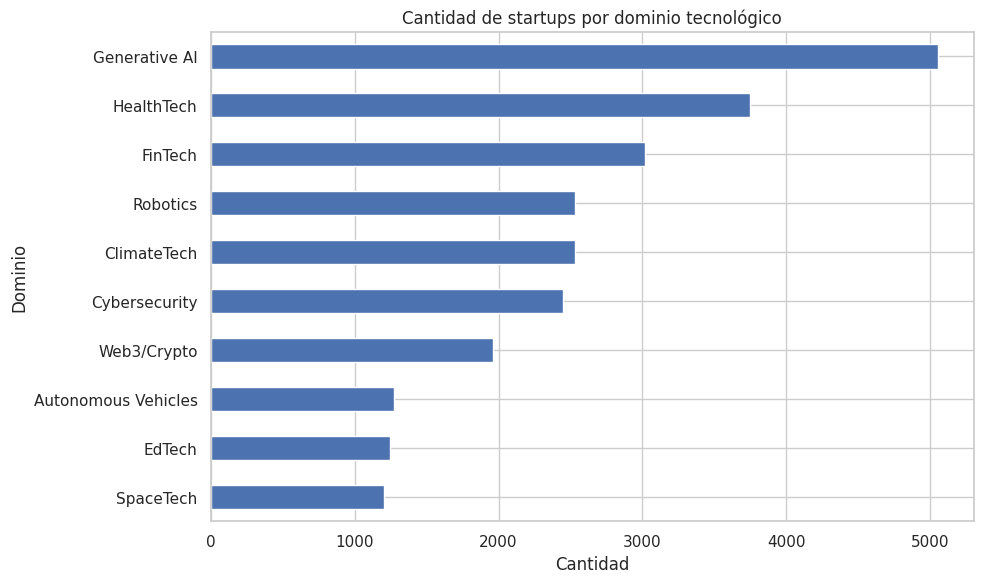

In [25]:
# 5.1 Startups por dominio
counts = df["Domain"].value_counts().sort_values()
display(counts.to_frame("Cantidad"))
plt.figure(figsize=(10,6))
counts.plot(kind="barh")
plt.title("Cantidad de startups por dominio tecnológico")
plt.xlabel("Cantidad")
plt.ylabel("Dominio")
plt.tight_layout()
plt.show()

,Cantidad
Country,
Japan,505
Singapore,751
France,790
Canada,1026
Germany,1270
Israel,1270
UK,1931
India,2478
China,3793


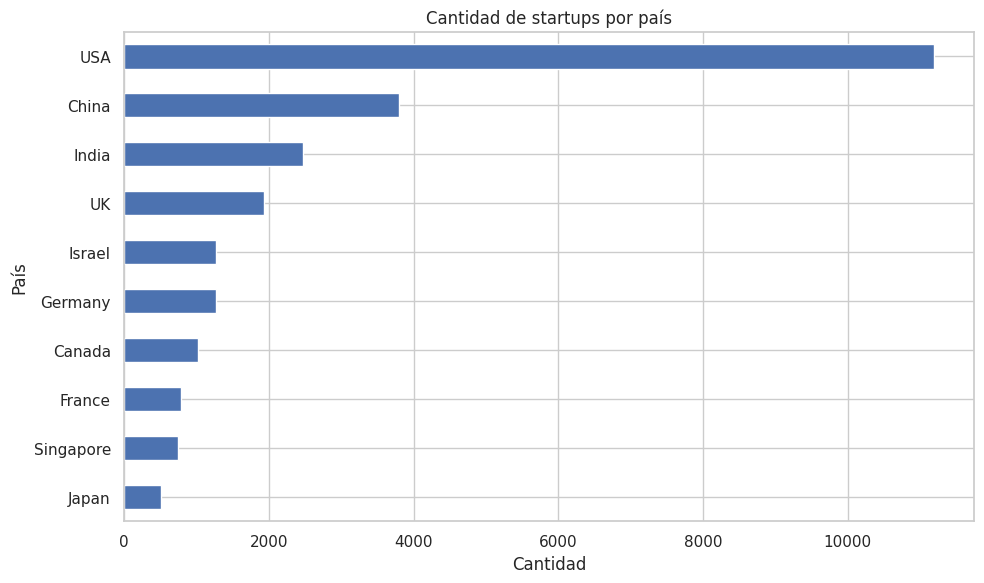

In [26]:
# 5.2 Startups por país
counts = df["Country"].value_counts().sort_values()
display(counts.to_frame("Cantidad"))
plt.figure(figsize=(10,6))
counts.plot(kind="barh")
plt.title("Cantidad de startups por país")
plt.xlabel("Cantidad")
plt.ylabel("País")
plt.tight_layout()
plt.show()

,Cantidad
Funding_Stage,
Seed,8686
Series A,6269
Series B,5018
Series C+,2966
Pre-IPO,1248
Post-IPO,813


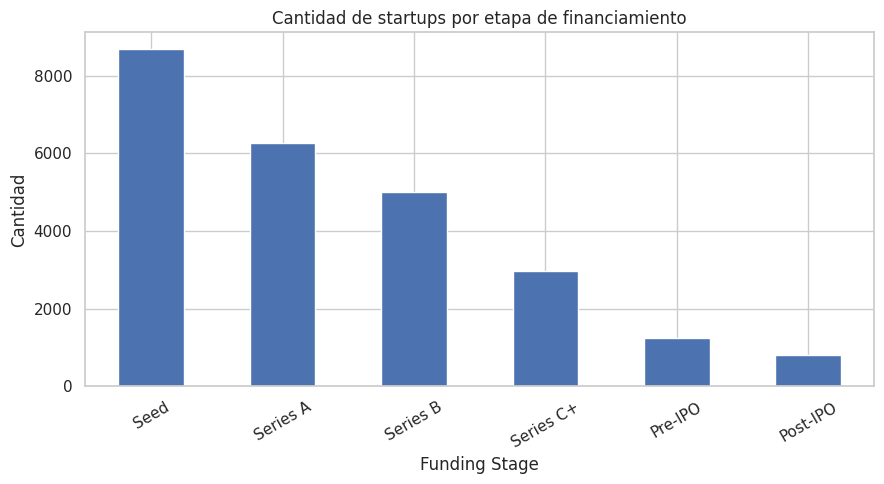

In [27]:
# 5.3 Startups por Funding Stage
stage_order = ["Seed", "Series A", "Series B", "Series C+", "Pre-IPO", "Post-IPO"]
stage_counts = df["Funding_Stage"].value_counts().reindex(stage_order)
display(stage_counts.to_frame("Cantidad"))
plt.figure(figsize=(9,5))
stage_counts.plot(kind="bar")
plt.title("Cantidad de startups por etapa de financiamiento")
plt.xlabel("Funding Stage")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. EDA - Distribuciones financieras

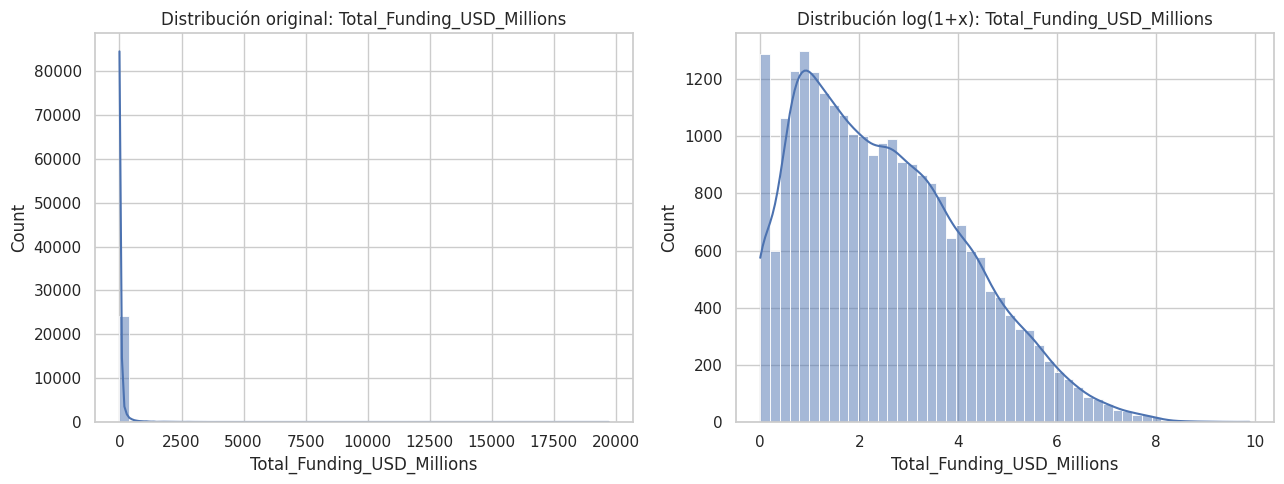

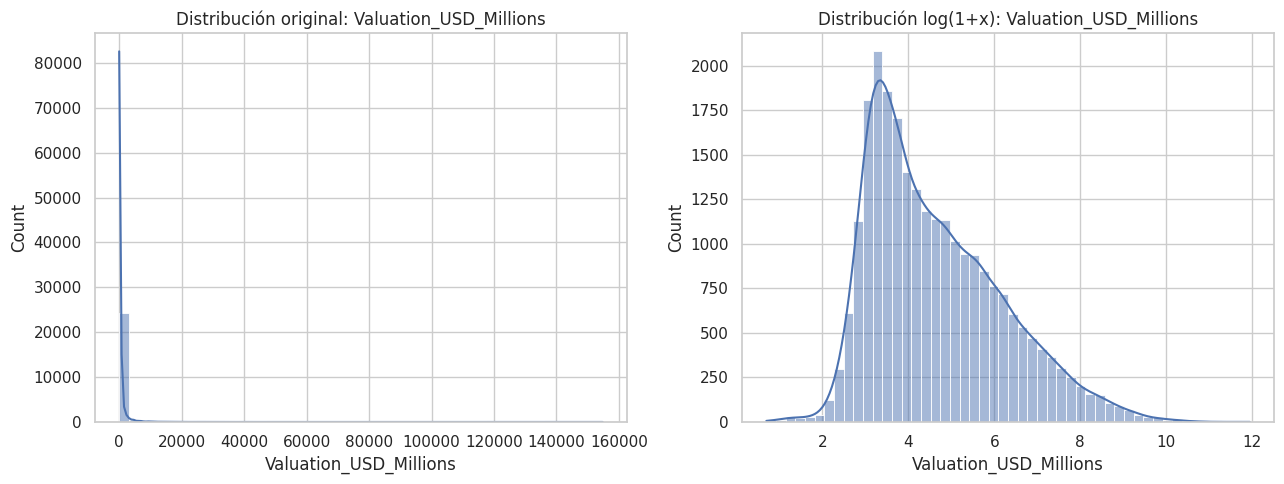

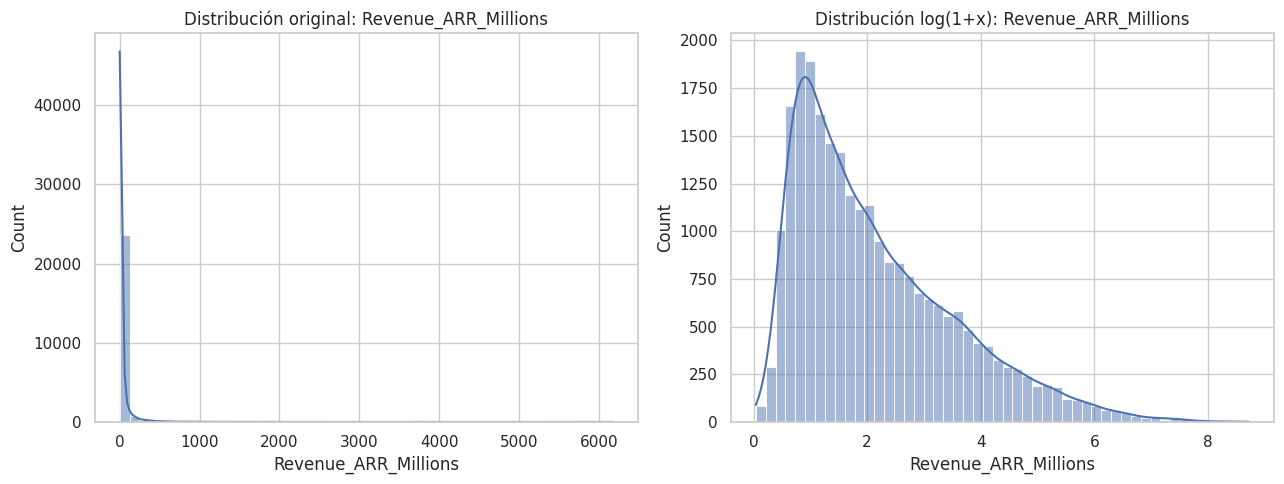

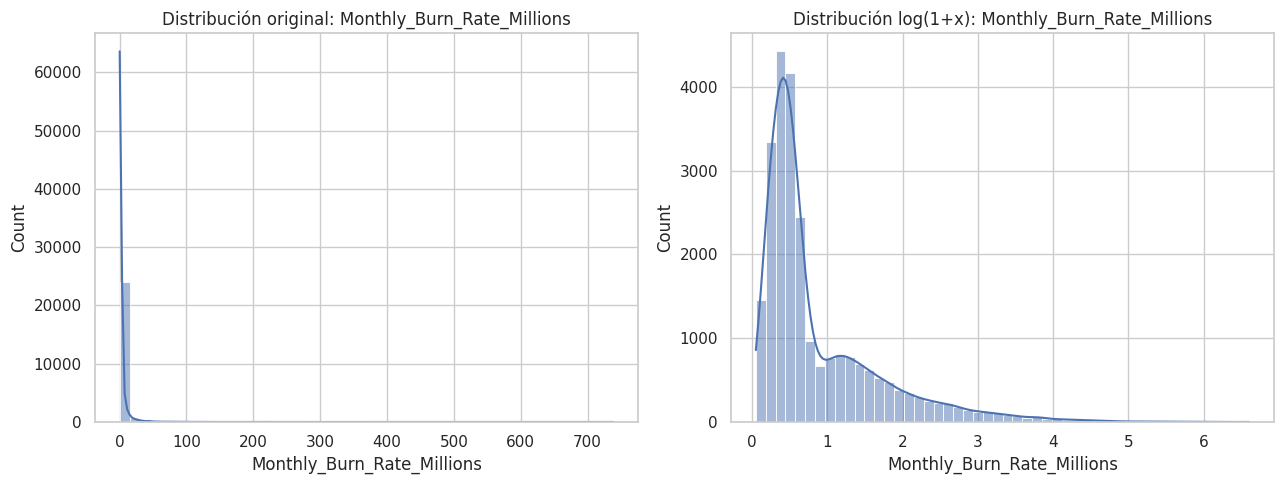

In [28]:
financial_cols = [
    "Total_Funding_USD_Millions",
    "Valuation_USD_Millions",
    "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions"
]

for col in financial_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13,5))
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución original: {col}")
    sns.histplot(np.log1p(df[col]), bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f"Distribución log(1+x): {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
new_financial_cols = [
    "Revenue_Burn_Ratio",
    "Revenue_Funding_Ratio"
]

for col in new_financial_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13,5))
    sns.histplot(df_model[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución original: {col}")
    sns.histplot(np.log1p(df_model[col]), bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f"Distribución log(1+x): {col}")
    plt.tight_layout()
    plt.show()

### Fix: Re-defining `df`

The previous cell using `df` (cell `744199f3`) encountered a `NameError` because `df` was not defined. This cell re-loads `df` to ensure subsequent operations work correctly.

In [29]:
from pathlib import Path
import pandas as pd

# Define CSV_PATH and load df, assuming this cell might be run out of order
CSV_PATH = Path("/content/global_tech_startups_2026.csv")
df = pd.read_csv(CSV_PATH)

## 7. Valuación por segmentos

,count,mean,median,std
Domain,,,,
Generative AI,5051,1011.444508,144.880,4034.872294
SpaceTech,1201,794.962182,115.550,2534.433301
Web3/Crypto,1958,444.161691,79.670,1257.499294
HealthTech,3744,358.335312,65.420,1198.257829
Cybersecurity,2451,305.473545,57.190,991.094712
Autonomous Vehicles,1271,333.271125,57.140,973.548627
Robotics,2529,316.369498,56.640,1072.092328
FinTech,3020,309.130960,56.450,1029.360992
EdTech,1246,279.480209,54.725,818.605461


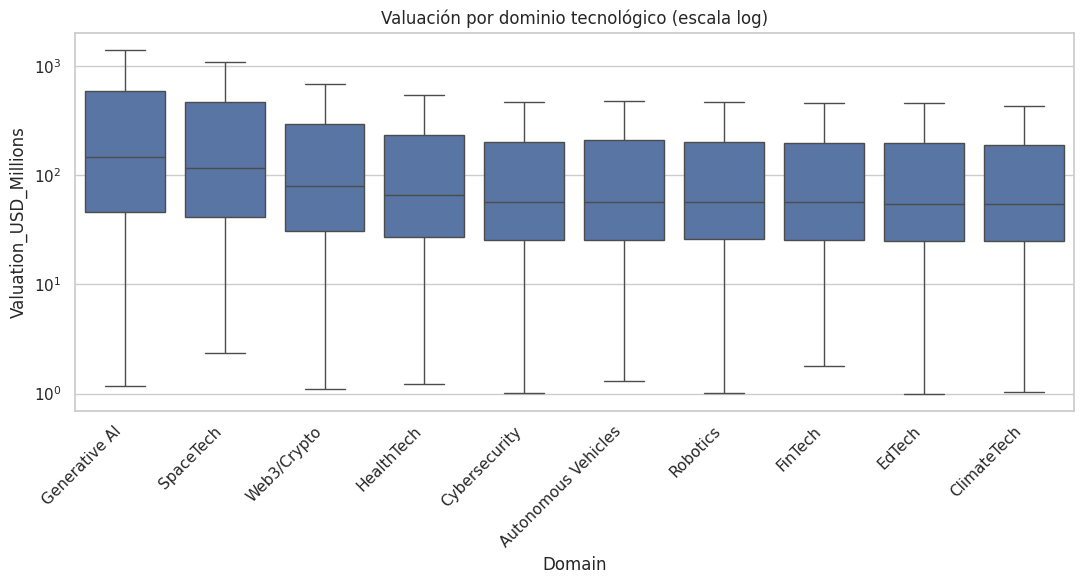

In [30]:
valuation_domain = (
    df.groupby("Domain")["Valuation_USD_Millions"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("median", ascending=False)
)
display(valuation_domain)

plt.figure(figsize=(11,6))
sns.boxplot(
    data=df, x="Domain", y="Valuation_USD_Millions",
    order=valuation_domain.index, showfliers=False
)
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Valuación por dominio tecnológico (escala log)")
plt.tight_layout()
plt.show()

,count,mean,median,std
Funding_Stage,,,,
Seed,8686,33.432778,25.510,31.273909
Series A,6269,116.401554,70.340,143.797112
Series B,5018,321.394861,189.515,439.067651
Series C+,2966,867.848311,479.930,1185.992388
Pre-IPO,1248,2255.609832,1205.180,5248.503358
Post-IPO,813,5234.862202,2881.100,7704.141021


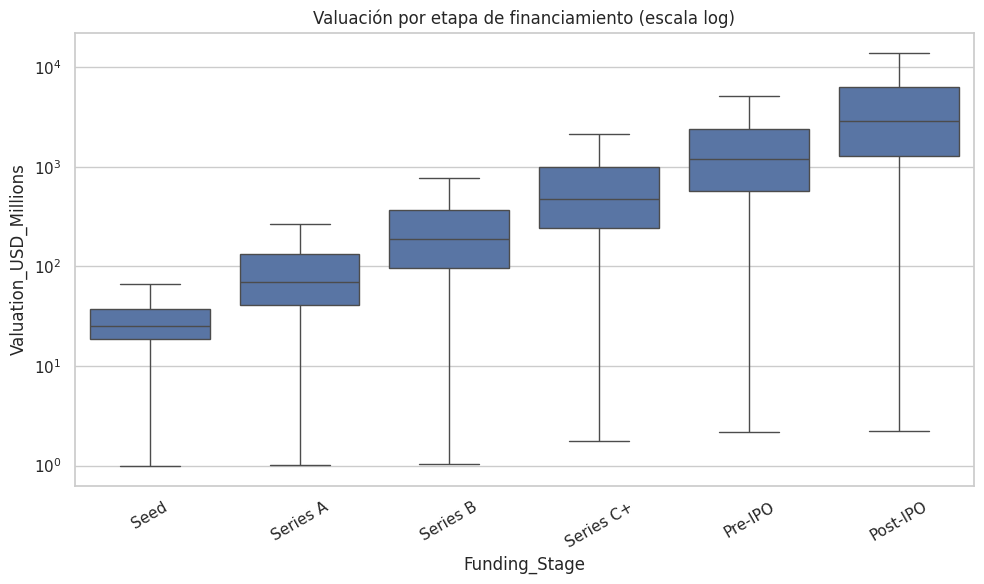

In [31]:
valuation_stage = (
    df.groupby("Funding_Stage")["Valuation_USD_Millions"]
      .agg(["count", "mean", "median", "std"])
      .reindex(stage_order)
)
display(valuation_stage)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df, x="Funding_Stage", y="Valuation_USD_Millions",
    order=stage_order, showfliers=False
)
plt.yscale("log")
plt.xticks(rotation=30)
plt.title("Valuación por etapa de financiamiento (escala log)")
plt.tight_layout()
plt.show()

In [32]:
valuation_country = (
    df.groupby("Country")["Valuation_USD_Millions"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("median", ascending=False)
)
display(valuation_country)

,count,mean,median,std
Country,,,,
India,2478,588.683313,81.740,4100.705273
UK,1931,458.482299,73.480,1764.146753
USA,11186,484.297305,73.445,1793.969818
Israel,1270,492.122189,73.240,1790.665199
China,3793,500.976631,72.260,1765.643978
France,790,497.747253,69.705,1744.659335
Japan,505,598.787762,68.340,2644.602578
Germany,1270,423.504709,64.420,1710.254190
Canada,1026,394.721433,63.305,1484.216147


## 8. Correlaciones y relaciones numéricas

Pearson


,Founding_Year,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions
Founding_Year,1.000,0.003,0.002,0.003,-0.011
Total_Funding_USD_Millions,0.003,1.000,0.959,0.828,0.929
Valuation_USD_Millions,0.002,0.959,1.000,0.872,0.886
Revenue_ARR_Millions,0.003,0.828,0.872,1.000,0.780
Monthly_Burn_Rate_Millions,-0.011,0.929,0.886,0.780,1.000


Spearman


,Founding_Year,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions
Founding_Year,1.000,0.011,0.009,0.007,-0.006
Total_Funding_USD_Millions,0.011,1.000,0.960,0.908,0.830
Valuation_USD_Millions,0.009,0.960,1.000,0.943,0.812
Revenue_ARR_Millions,0.007,0.908,0.943,1.000,0.777
Monthly_Burn_Rate_Millions,-0.006,0.830,0.812,0.777,1.000


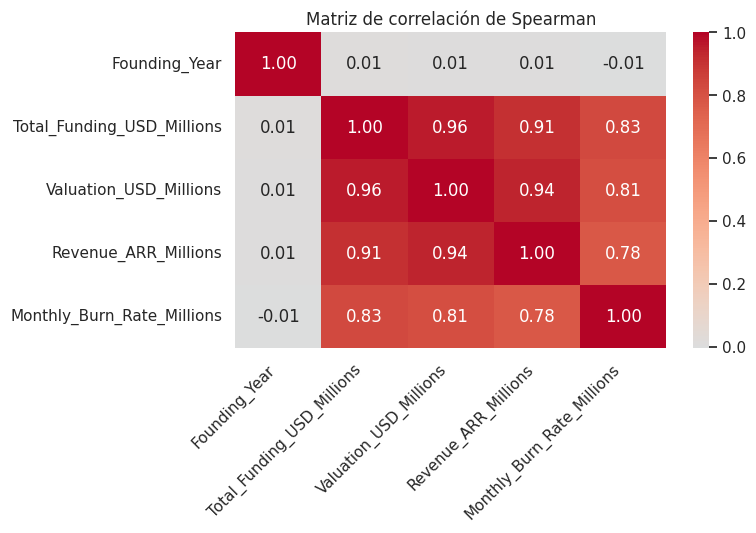

In [39]:
numeric_cols = [
    "Founding_Year",
    "Total_Funding_USD_Millions",
    "Valuation_USD_Millions",
    "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions"
]

pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")
print("Pearson")
display(pearson_corr.round(3))
print("Spearman")
display(spearman_corr.round(3))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

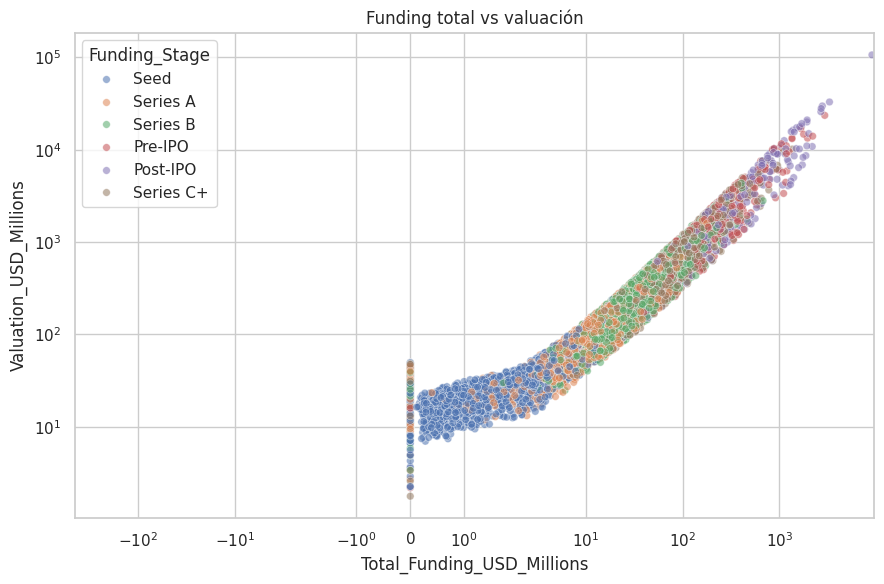

In [40]:
sample_plot = df.sample(min(6000, len(df)), random_state=RANDOM_STATE)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=sample_plot,
    x="Total_Funding_USD_Millions",
    y="Valuation_USD_Millions",
    hue="Funding_Stage", alpha=0.55, s=30
)
plt.xscale("symlog")
plt.yscale("log")
plt.title("Funding total vs valuación")
plt.tight_layout()
plt.show()

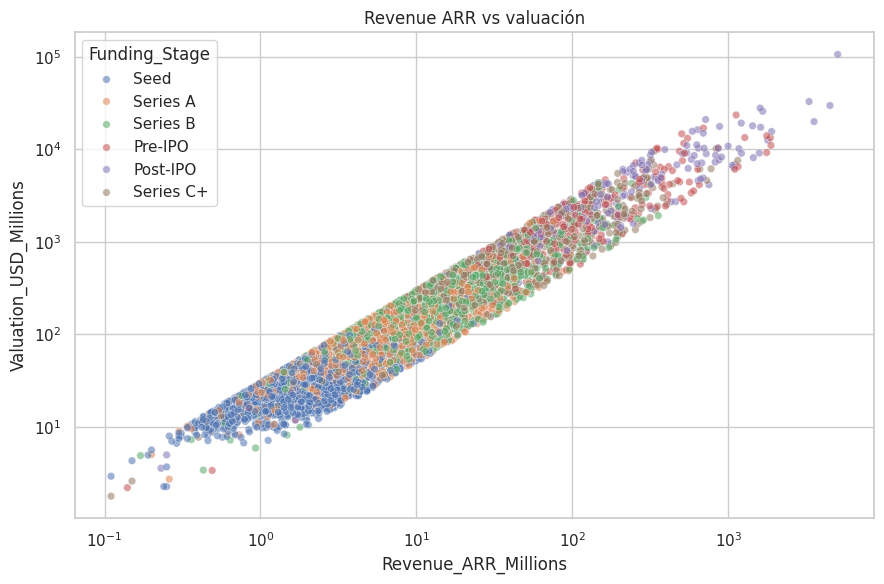

In [41]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=sample_plot,
    x="Revenue_ARR_Millions",
    y="Valuation_USD_Millions",
    hue="Funding_Stage", alpha=0.55, s=30
)
plt.xscale("log")
plt.yscale("log")
plt.title("Revenue ARR vs valuación")
plt.tight_layout()
plt.show()

**#Esta relación es la métrica clave para entender si una empresa está sobrevalorada o subvalorada respecto a lo que realmente factura.#** Luciana #podriamos agregar una linea de tendencia#

## 9. Contraste de hipótesis

In [43]:
rho_funding, p_funding = spearmanr(df["Total_Funding_USD_Millions"], df["Valuation_USD_Millions"])
rho_arr, p_arr = spearmanr(df["Revenue_ARR_Millions"], df["Valuation_USD_Millions"])

stage_groups = [g["Valuation_USD_Millions"].values for _, g in df.groupby("Funding_Stage")]
kw_stage, p_kw_stage = kruskal(*stage_groups)

domain_groups = [g["Valuation_USD_Millions"].values for _, g in df.groupby("Domain")]
kw_domain, p_kw_domain = kruskal(*domain_groups)

hypothesis_results = pd.DataFrame({
    "Hipótesis": [
        "Funding asociado a valuación",
        "ARR asociado a valuación",
        "Valuación difiere por Funding Stage",
        "Valuación difiere por Domain"
    ],
    "Estadístico": [rho_funding, rho_arr, kw_stage, kw_domain],
    "p_value": [p_funding, p_arr, p_kw_stage, p_kw_domain]
})
hypothesis_results["Significativo_5pct"] = hypothesis_results["p_value"] < 0.05
display(hypothesis_results)

,Hipótesis,Estadístico,p_value,Significativo_5pct
0,Funding asociado a valuación,0.959628,0.000000e+00,True
1,ARR asociado a valuación,0.942634,0.000000e+00,True
2,Valuación difiere por Funding Stage,15713.233029,0.000000e+00,True
3,Valuación difiere por Domain,1160.849708,3.425924e-244,True


## 10. Preparación para Machine Learning

### Fix: Re-defining `df_model` and its features

The previous cell using `df_model` (cell `d0994b83`) encountered a `NameError` because `df_model` was not defined. This cell re-creates `df_model` and its engineered features, ensuring dependent operations proceed without errors.

In [45]:
import numpy as np

# Re-create df_model and its features, assuming this cell might be run out of order
df_model = df.copy()
df_model["Startup_Age"] = 2026 - df_model["Founding_Year"]
df_model["Annual_Burn_Millions"] = df_model["Monthly_Burn_Rate_Millions"] * 12
EPS = 1e-6 # Ensure EPS is defined

df_model["Revenue_Burn_Ratio"] = (
    df_model["Revenue_ARR_Millions"] / (df_model["Annual_Burn_Millions"] + EPS)
)
df_model["Revenue_Funding_Ratio"] = (
    df_model["Revenue_ARR_Millions"] / (df_model["Total_Funding_USD_Millions"] + EPS)
)

In [47]:
features = [
    "Domain", "Country", "City", "Funding_Stage",
    "Startup_Age", "Total_Funding_USD_Millions",
    "Revenue_ARR_Millions", "Monthly_Burn_Rate_Millions",
    "Annual_Burn_Millions", "Revenue_Burn_Ratio", "Revenue_Funding_Ratio"
]
target = "Valuation_USD_Millions"

X = df_model[features].copy()
y = df_model[target].copy()
y_log = np.log1p(y)

categorical_features = ["Domain", "Country", "City", "Funding_Stage"]
numeric_features = [
    "Startup_Age", "Total_Funding_USD_Millions", "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions", "Annual_Burn_Millions",
    "Revenue_Burn_Ratio", "Revenue_Funding_Ratio"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.20, random_state=RANDOM_STATE
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (20000, 11)
Test: (5000, 11)


## 11. Entrenamiento y comparación de modelos

In [48]:
models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    )
}

results = []
fitted_models = {}
y_test_original = np.expm1(y_test_log)

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train_log)
    pred_log = pipeline.predict(X_test)
    pred_original = np.clip(np.expm1(pred_log), 0, None)

    results.append({
        "Modelo": name,
        "MAE_USD_Millions": mean_absolute_error(y_test_original, pred_original),
        "RMSE_USD_Millions": np.sqrt(mean_squared_error(y_test_original, pred_original)),
        "R2_original": r2_score(y_test_original, pred_original),
        "R2_log": r2_score(y_test_log, pred_log)
    })
    fitted_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("R2_log", ascending=False)
display(results_df)

,Modelo,MAE_USD_Millions,RMSE_USD_Millions,R2_original,R2_log
3,Gradient Boosting,111.266318,7.681045e+02,0.874214,0.972993
2,Random Forest,112.159633,6.871231e+02,0.899339,0.971618
1,Linear Regression,28663.139820,1.996530e+06,-849850.551157,0.766506
0,Dummy,467.953854,2.202287e+03,-0.034045,-0.001082


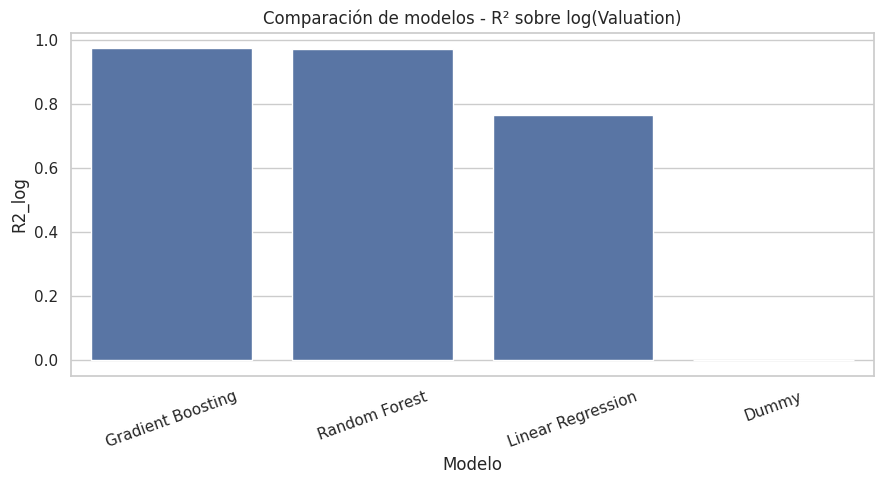

In [49]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="Modelo", y="R2_log")
plt.title("Comparación de modelos - R² sobre log(Valuation)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 12. Mejor modelo: real vs predicho

Mejor modelo: Gradient Boosting


,Real,Predicho
6868,22.57,21.281766
24016,33.89,30.556576
9668,181.50,152.151356
13640,74.44,80.878364
14018,6422.87,4747.855704


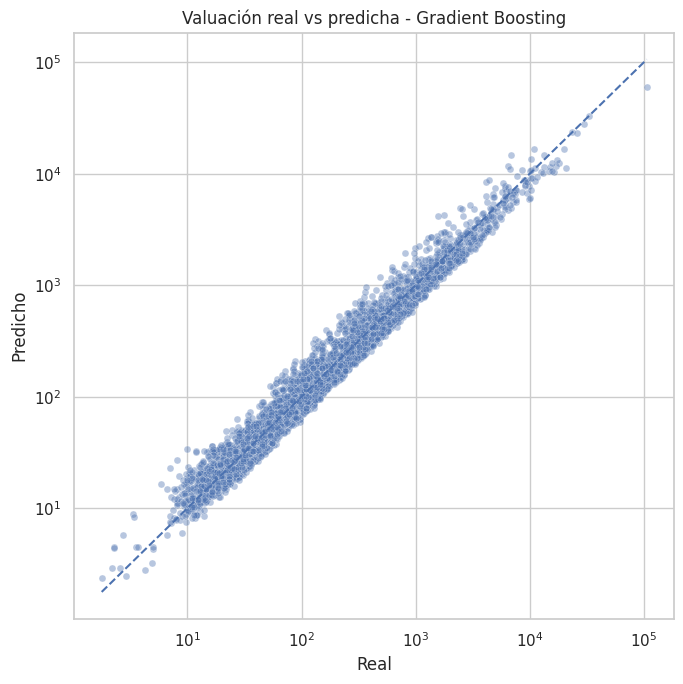

In [50]:
best_model_name = results_df.iloc[0]["Modelo"]
best_pipeline = fitted_models[best_model_name]
print("Mejor modelo:", best_model_name)

best_pred_log = best_pipeline.predict(X_test)
best_pred_original = np.clip(np.expm1(best_pred_log), 0, None)
plot_predictions = pd.DataFrame({"Real": y_test_original, "Predicho": best_pred_original})
display(plot_predictions.head())

plt.figure(figsize=(7,7))
sns.scatterplot(data=plot_predictions, x="Real", y="Predicho", alpha=0.4, s=25)
max_val = max(plot_predictions["Real"].max(), plot_predictions["Predicho"].max())
min_positive = max(0.01, min(
    plot_predictions.loc[plot_predictions["Real"]>0, "Real"].min(),
    plot_predictions.loc[plot_predictions["Predicho"]>0, "Predicho"].min()
))
plt.plot([min_positive, max_val], [min_positive, max_val], linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Valuación real vs predicha - {best_model_name}")
plt.tight_layout()
plt.show()

## 13. Validación cruzada

In [51]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipeline, X, y_log, cv=cv, scoring="r2", n_jobs=-1)
cv_df = pd.DataFrame({"Fold": range(1,6), "R2_log": cv_scores})
display(cv_df)
print(f"R² medio: {cv_scores.mean():.4f}")
print(f"Desvío: {cv_scores.std():.4f}")

,Fold,R2_log
0,1,0.972993
1,2,0.973163
2,3,0.973051
3,4,0.973898
4,5,0.974184


R² medio: 0.9735
Desvío: 0.0005


## 14. Importancia de variables - Random Forest

,Feature,Importance
1,num__Total_Funding_USD_Millions,0.942460
2,num__Revenue_ARR_Millions,0.039224
6,num__Revenue_Funding_Ratio,0.004314
5,num__Revenue_Burn_Ratio,0.002743
0,num__Startup_Age,0.001976
3,num__Monthly_Burn_Rate_Millions,0.001327
4,num__Annual_Burn_Millions,0.001326
26,cat__Country_USA,0.000400
12,cat__Domain_Generative AI,0.000320
13,cat__Domain_HealthTech,0.000300


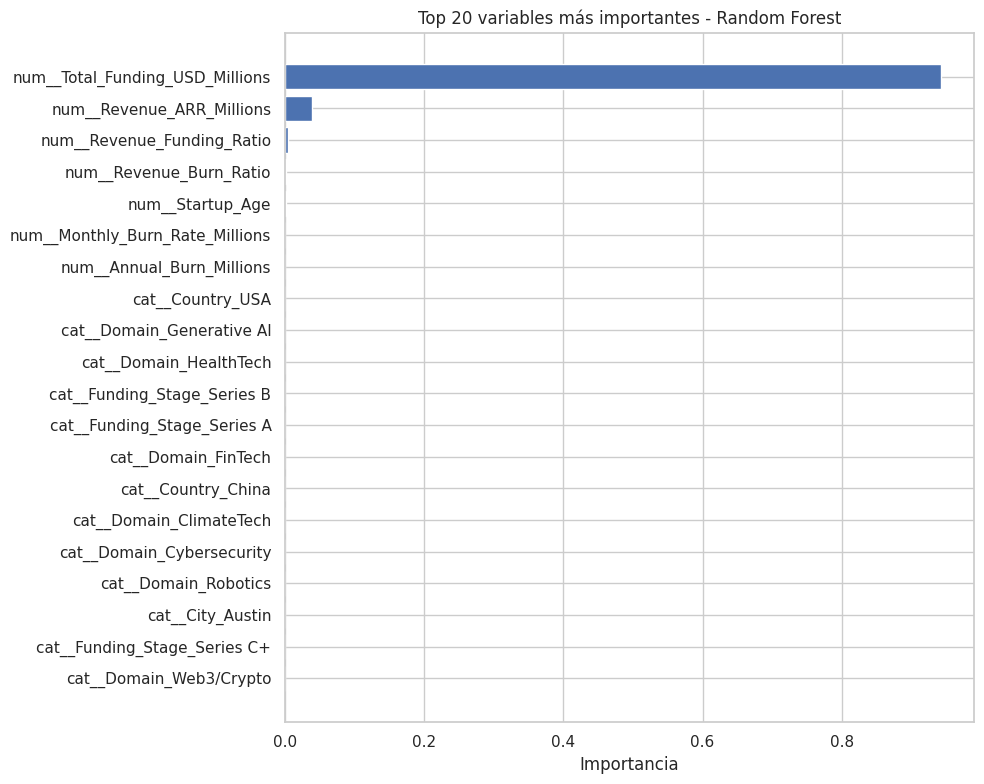

In [52]:
rf_pipeline = fitted_models["Random Forest"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]
feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

top_imp = importance_df.head(20).sort_values("Importance")
plt.figure(figsize=(10,8))
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.title("Top 20 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## 15. Análisis de residuos

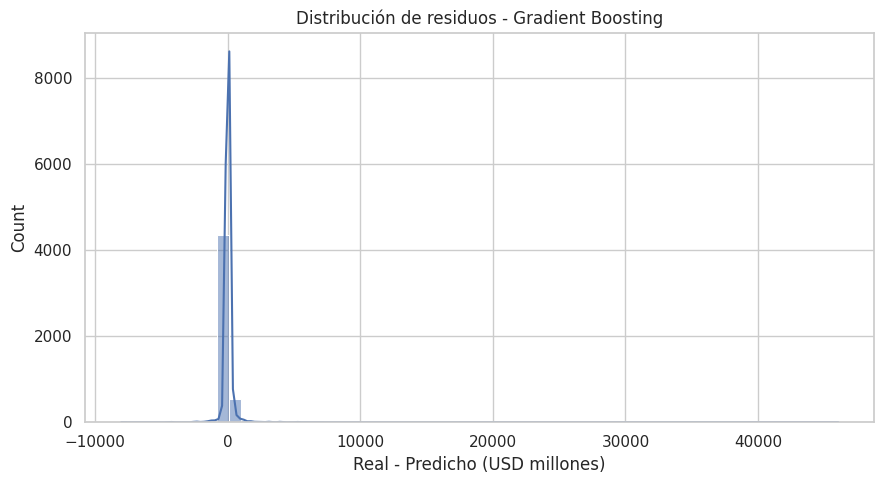

,Real,Predicho,Residual,Abs_Error
1465,106376.86,60329.761911,46047.098089,46047.098089
1205,21012.62,11261.881205,9750.738795,9750.738795
12,6856.82,14900.488370,-8043.668370,8043.668370
656,16333.05,10373.086728,5959.963272,5959.963272
3240,10837.05,16674.441144,-5837.391144,5837.391144
1803,6400.62,11849.948209,-5449.328209,5449.328209
763,17966.67,12585.242095,5381.427905,5381.427905
2065,16981.24,11657.107898,5324.132102,5324.132102
3914,15696.41,10555.547169,5140.862831,5140.862831
2763,4435.68,8844.172379,-4408.492379,4408.492379


In [53]:
residuals = y_test_original.values - best_pred_original
plt.figure(figsize=(9,5))
sns.histplot(residuals, bins=60, kde=True)
plt.title(f"Distribución de residuos - {best_model_name}")
plt.xlabel("Real - Predicho (USD millones)")
plt.tight_layout()
plt.show()

error_df = pd.DataFrame({
    "Real": y_test_original.values,
    "Predicho": best_pred_original,
    "Residual": residuals,
    "Abs_Error": np.abs(residuals)
})
display(error_df.sort_values("Abs_Error", ascending=False).head(10))

AGREGARIA ETIQUETA PARA SABER CUAL ES EL REAL DEL PREDICHO

## 16. Clustering opcional

,k,silhouette
0,2,0.483350
1,3,0.367280
2,4,0.362866
3,5,0.335623
4,6,0.339340


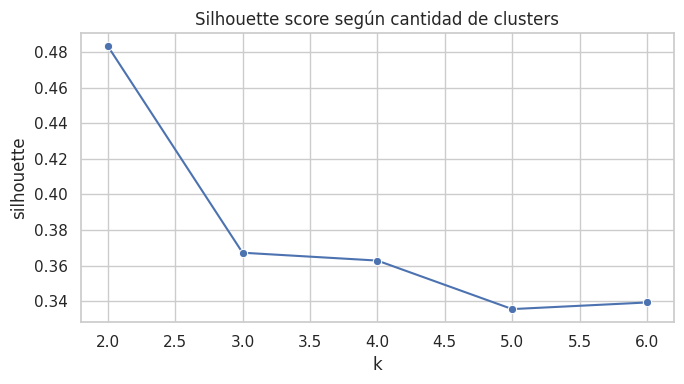

In [54]:
cluster_features = [
    "Total_Funding_USD_Millions",
    "Valuation_USD_Millions",
    "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions",
    "Startup_Age"
]
cluster_df = df_model[cluster_features].copy()
for col in cluster_features[:-1]:
    cluster_df[col] = np.log1p(cluster_df[col])

cluster_scaled = StandardScaler().fit_transform(cluster_df)
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(cluster_scaled), size=min(5000, len(cluster_scaled)), replace=False)

silhouette_results = []
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    sil = silhouette_score(cluster_scaled[sample_idx], labels[sample_idx])
    silhouette_results.append({"k": k, "silhouette": sil})

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

plt.figure(figsize=(7,4))
sns.lineplot(data=silhouette_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette score según cantidad de clusters")
plt.tight_layout()
plt.show()

Mejor k: 2


,Cantidad,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Startup_Age
Cluster,,,,,,
0,7663,76.11,558.20,37.79,4.11,6.0
1,17337,3.60,39.53,2.59,0.53,7.0


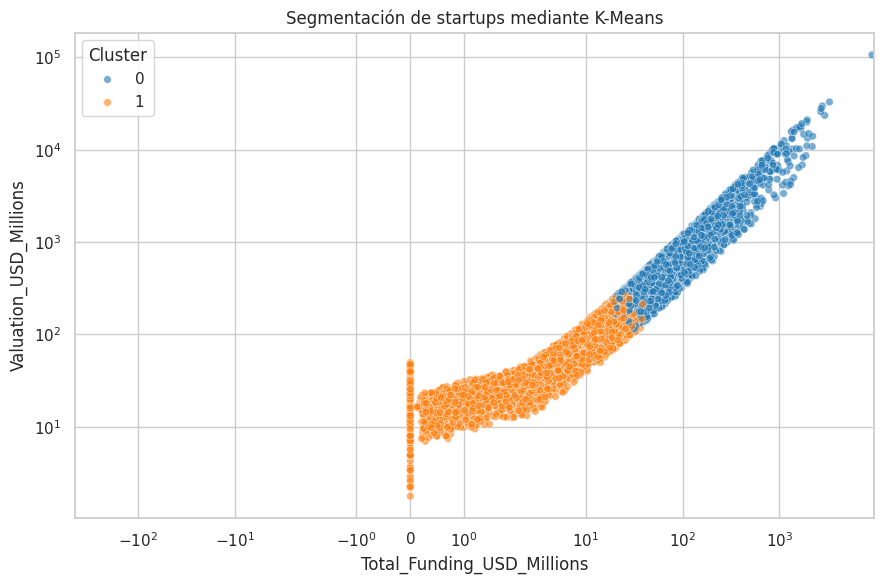

In [55]:
best_k = int(silhouette_df.loc[silhouette_df["silhouette"].idxmax(), "k"])
print("Mejor k:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_profile = (
    df_model.groupby("Cluster")
    .agg({
        "Company_ID": "count",
        "Total_Funding_USD_Millions": "median",
        "Valuation_USD_Millions": "median",
        "Revenue_ARR_Millions": "median",
        "Monthly_Burn_Rate_Millions": "median",
        "Startup_Age": "median"
    })
    .rename(columns={"Company_ID": "Cantidad"})
)
display(cluster_profile)

cluster_sample = df_model.sample(min(6000, len(df_model)), random_state=RANDOM_STATE)
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=cluster_sample,
    x="Total_Funding_USD_Millions",
    y="Valuation_USD_Millions",
    hue="Cluster", palette="tab10", alpha=0.6, s=30
)
plt.xscale("symlog")
plt.yscale("log")
plt.title("Segmentación de startups mediante K-Means")
plt.tight_layout()
plt.show()

## 17. Resumen final

In [56]:
top_domain = df.groupby("Domain")["Valuation_USD_Millions"].median().idxmax()
top_country = df.groupby("Country")["Valuation_USD_Millions"].median().idxmax()
top_stage = df.groupby("Funding_Stage")["Valuation_USD_Millions"].median().idxmax()
best_result = results_df.iloc[0]

print(f"""
Dataset analizado:
- {len(df):,} startups
- {df['Domain'].nunique()} dominios tecnológicos
- {df['Country'].nunique()} países
- {df['City'].nunique()} ciudades
- {df['Funding_Stage'].nunique()} etapas de financiamiento

Calidad:
- Missing values: {int(df.isna().sum().sum())}
- Duplicados: {int(df.duplicated().sum())}

Hallazgos descriptivos:
- Dominio con mayor mediana de valuación: {top_domain}
- País con mayor mediana de valuación: {top_country}
- Etapa con mayor mediana de valuación: {top_stage}

Relaciones:
- Spearman Funding vs Valuation: {rho_funding:.3f}
- Spearman ARR vs Valuation: {rho_arr:.3f}

Mejor modelo:
- {best_result['Modelo']}
- R² log: {best_result['R2_log']:.3f}
- R² escala original: {best_result['R2_original']:.3f}
- MAE: {best_result['MAE_USD_Millions']:,.2f} millones USD
- RMSE: {best_result['RMSE_USD_Millions']:,.2f} millones USD

Interpretación:
Los resultados muestran asociaciones y capacidad predictiva; no implican causalidad.
""")


Dataset analizado:
- 25,000 startups
- 10 dominios tecnológicos
- 10 países
- 29 ciudades
- 6 etapas de financiamiento

Calidad:
- Missing values: 2529
- Duplicados: 0

Hallazgos descriptivos:
- Dominio con mayor mediana de valuación: Generative AI
- País con mayor mediana de valuación: India
- Etapa con mayor mediana de valuación: Post-IPO

Relaciones:
- Spearman Funding vs Valuation: 0.960
- Spearman ARR vs Valuation: 0.943

Mejor modelo:
- Gradient Boosting
- R² log: 0.973
- R² escala original: 0.874
- MAE: 111.27 millones USD
- RMSE: 768.10 millones USD

Interpretación:
Los resultados muestran asociaciones y capacidad predictiva; no implican causalidad.

